In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_hermite, gammaln

from core.IntensityModes import laguerre_gauss as Lg
from core.IntensityModes import hermite_gauss as Hg, hg_1d_n as Hg_1d
from core.PolarizationModes import optical_element, scalar_to_vector, filter_polarizer, q_plate as qp
from core.masks import turbulence_mask as turb
from core.metrics import intensity as I, power as pwr, phase as phi, inner_product
from core.propagation import angular_spectrum as angSpec

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from PIL import Image

from tqdm import trange

power = 1.0000
the field has dimension 2, and shape (1000, 1000) before being a polarized field
the field has dimension 3, and shape (1000, 1000, 2) after being a polarized field
power after being transformed in a vector field = 1.0000
power element 1 = 1.0000
power element 2 = 0.0000


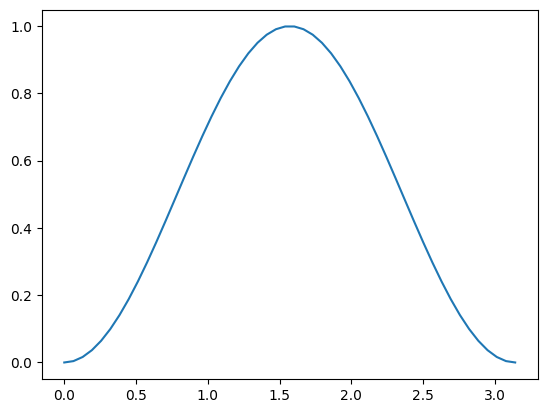

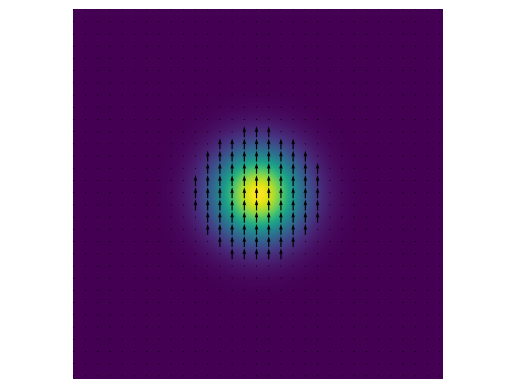

In [2]:
x = np.linspace(-.3e-2,.3e-2,1000)
y = np.linspace(-.3e-2,.3e-2,1000)
x,y = np.meshgrid(x,y)

# crating the scalar field and measure the power
lg = Hg(x,y,0,0)
print(f'power = {pwr(x,y,lg):.4f}')


# transforming the scalar field in a vector field (no need to do it like that, the optical_element() function do it automaticaly)(educational purposes)
print(f'the field has dimension {lg.ndim}, and shape {lg.shape} before being a polarized field') # the dimension and shape of the field/array before being a polarized
lg = scalar_to_vector(lg) # creating a polarized field from a scalar field
print(f'the field has dimension {lg.ndim}, and shape {lg.shape} after being a polarized field') # the dimension and shape of the field/array after being a polarized

print(f'power after being transformed in a vector field = {pwr(x,y,lg):.4f}') # seeing if the power keep normalized

# passing the beam through a half wave plate
lg = optical_element(x,y,lg,np.pi/4,'half')
print(f'power element 1 = {pwr(x,y,lg):.4f}')

# passing the beam through different polarizers
theta = np.linspace(0,np.pi,50)
value = []

for t in theta:
    lg_filter = filter_polarizer(x,y,lg,t,'linear')
    value.append(pwr(x,y,lg_filter))

plt.plot(theta,value)
print(f'power element 2 = {pwr(x,y,lg_filter):.4f}')


I(lg,vector_field=True,animate=True,scale=45)
plt.show()